### Dawar Ahmed 
### 24I-2533

### **Task - 1** 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
 df = pd.read_csv('adult.csv')

In [5]:
# Data Cleaning 
df_clean = df[df['occupation'] != '?']

In [8]:
# avg hours 
avg_hours = df_clean.groupby('occupation')['hours.per.week'].mean().sort_values(ascending=False)
avg_hours

occupation
Farming-fishing      46.989940
Exec-managerial      44.987703
Transport-moving     44.656230
Protective-serv      42.870570
Prof-specialty       42.386715
Craft-repair         42.304221
Sales                40.781096
Machine-op-inspct    40.755744
Armed-Forces         40.666667
Tech-support         39.432112
Handlers-cleaners    37.947445
Adm-clerical         37.558355
Other-service        34.701669
Priv-house-serv      32.885906
Name: hours.per.week, dtype: float64

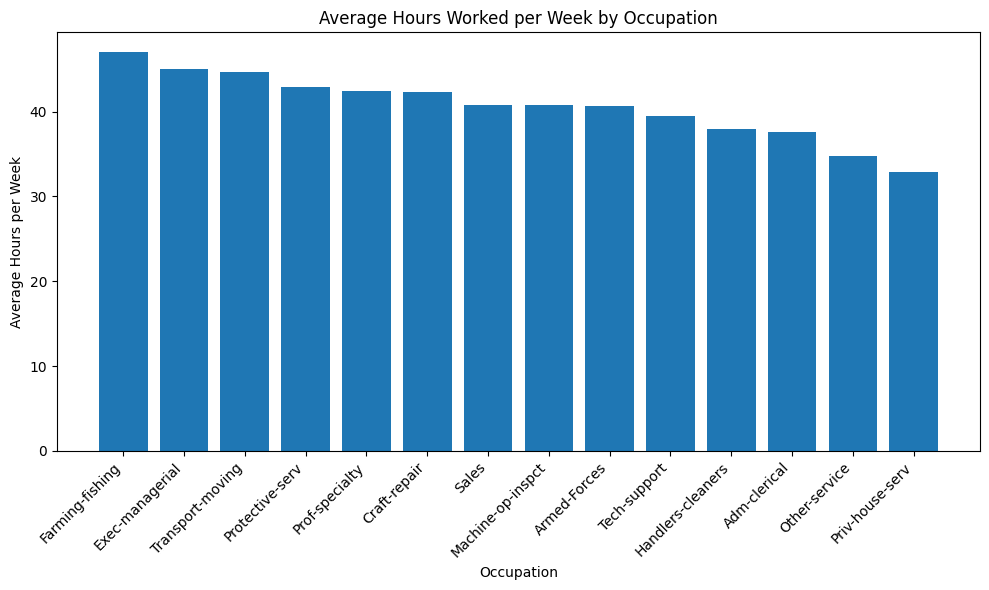

In [9]:
plt.figure(figsize=(10,6))
plt.bar(avg_hours.index, avg_hours.values)
plt.xlabel('Occupation')
plt.ylabel('Average Hours per Week')
plt.title('Average Hours Worked per Week by Occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Task - 2** 

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

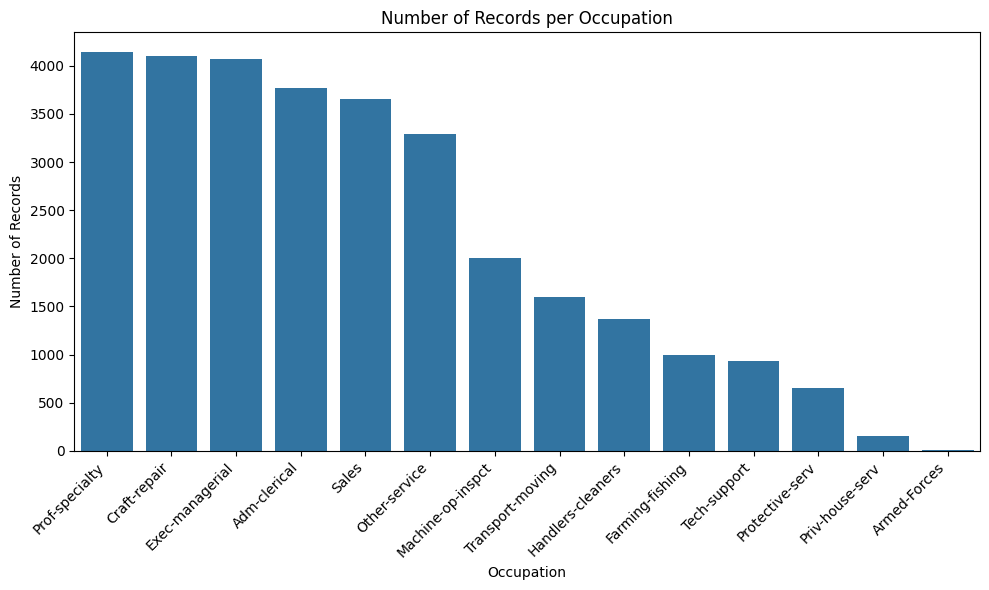

In [12]:
plt.figure(figsize=(10,6))

# count and plot in order. 
sns.countplot(data=df_clean, x='occupation', order=df_clean['occupation'].value_counts().index)

plt.xlabel('Occupation')
plt.ylabel('Number of Records')
plt.title('Number of Records per Occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
print(f"The most common category is {df_clean['occupation'].value_counts().idxmax()}")

The most common category is Prof-specialty


### **Task - 3** 

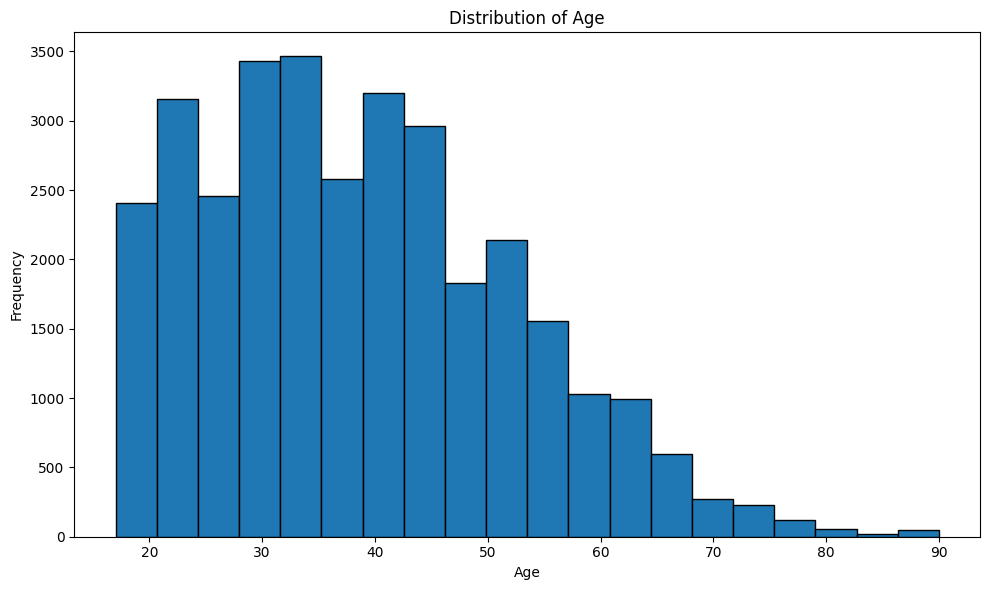

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.tight_layout()
plt.show()

### The plot is right skewed

### **Task - 4** 

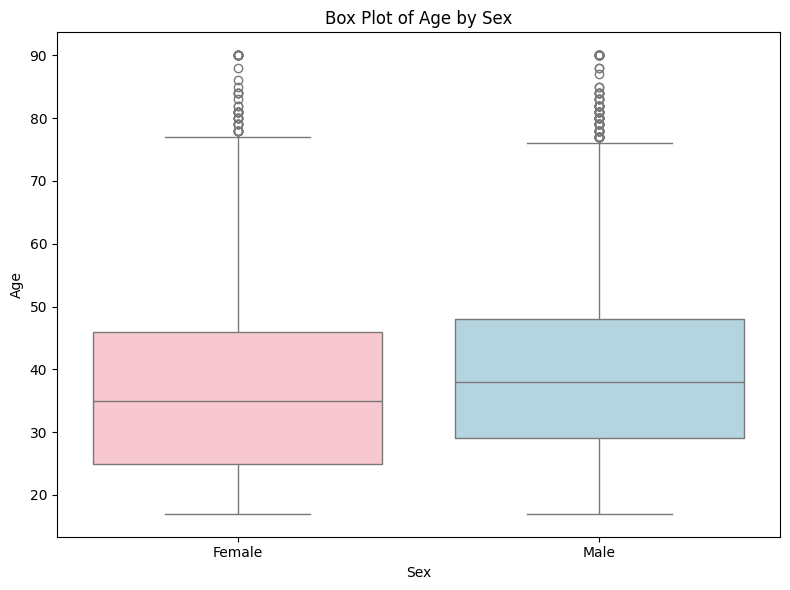

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='sex', y='age', hue='sex', palette={'Male': 'lightblue', 'Female': 'pink'}, legend=False)
plt.xlabel('Sex')
plt.ylabel('Age')
plt.title('Box Plot of Age by Sex')
plt.tight_layout()
plt.show()

### **Task - 5** 

In [ ]:
#calculating quartiles. 
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 28.0, Q3: 48.0, IQR: 20.0


In [32]:
#calculating bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -2.0, Upper Bound: 78.0


In [ ]:
#filtering the outliers. 
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")



Number of outliers: 143


### **Task - 6** 

In [38]:
from scipy import stats

In [39]:
df['zscore'] = stats.zscore(df['age'])

In [40]:
outliers_z = df[df['zscore'].abs() > 3]
print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 121


#### "IQR gave a more accurate outlier count (143) because it makes no assumption about the shape of the data — it simply uses quartile positions. Z-score, on the other hand, assumes the data follows a normal (bell-curve) distribution, which age does not (it is right-skewed). Because this assumption doesn't hold, Z-score's boundary becomes distorted, leading to a less accurate result (121)."

### **Task - 7** 

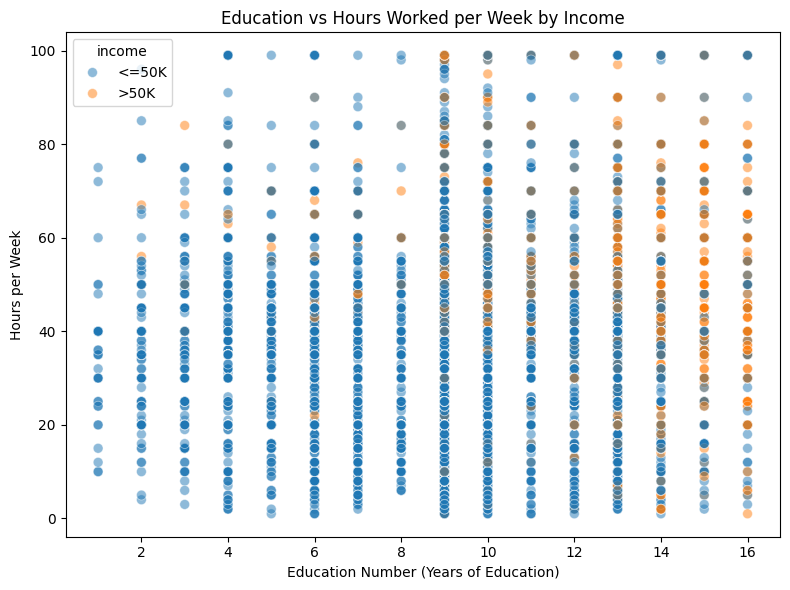

In [51]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='education.num', y='hours.per.week', hue='income', alpha=0.5, s = 50)
plt.xlabel('Education Number (Years of Education)')
plt.ylabel('Hours per Week')
plt.title('Education vs Hours Worked per Week by Income')
plt.tight_layout()
plt.show()

#### There is no clear relationship between education level and hours worked per week the data forms vertical stripes with a dense cluster around 40 hours regardless of education. However, coloring by income reveals that higher education levels are associated with a higher proportion of >50K earners, even though hours worked doesn't change much.

### **Task - 8** 

In [52]:
avg_hours_by_edu = df.groupby('education.num')['hours.per.week'].mean()
print(avg_hours_by_edu)

education.num
1     36.647059
2     38.255952
3     38.897898
4     39.366873
5     38.044747
6     37.052519
7     33.925957
8     35.780600
9     40.575374
10    38.852284
11    41.610709
12    40.504217
13    42.614006
14    43.836332
15    47.425347
16    46.973366
Name: hours.per.week, dtype: float64


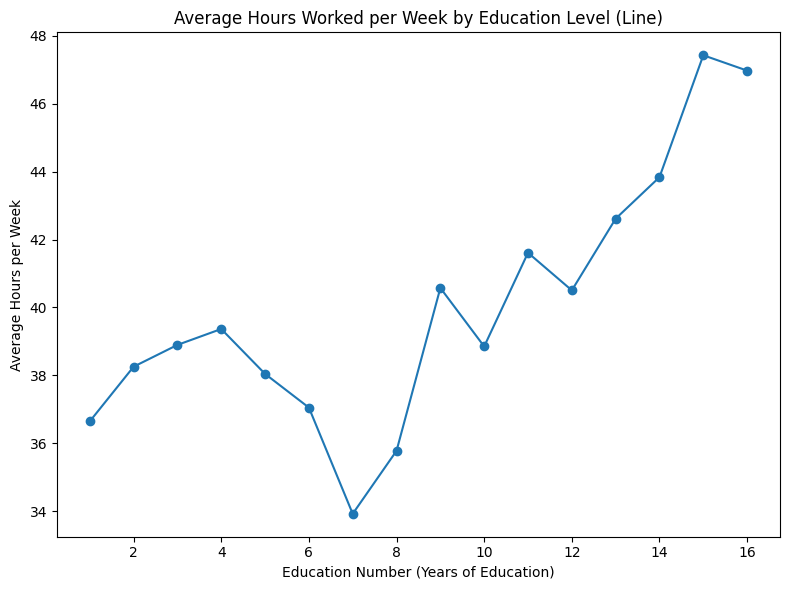

In [ ]:
#line chart

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker='o')
plt.xlabel('Education Number (Years of Education)')
plt.ylabel('Average Hours per Week')
plt.title('Average Hours Worked per Week by Education Level (Line)')
plt.tight_layout()
plt.show()

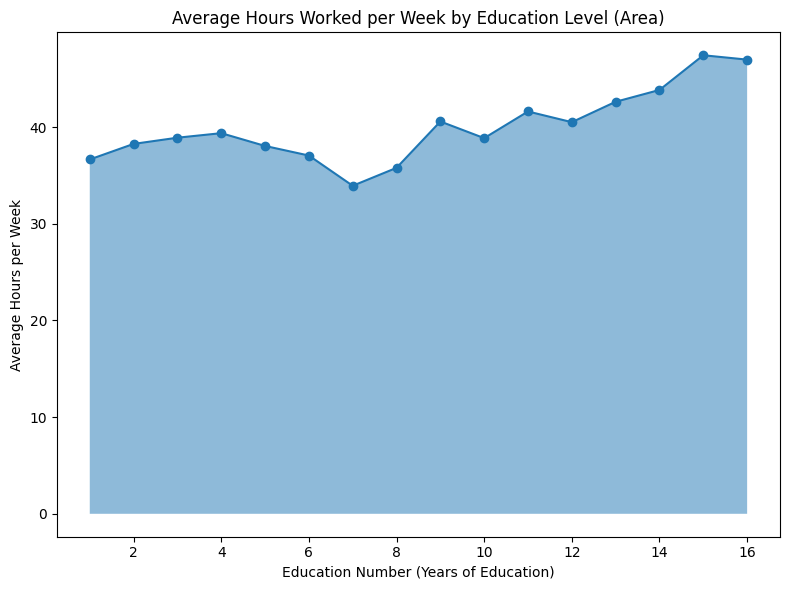

In [ ]:
#area chart

plt.figure(figsize=(8,6))
plt.fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, alpha=0.5)
plt.plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker='o')
plt.xlabel('Education Number (Years of Education)')
plt.ylabel('Average Hours per Week')
plt.title('Average Hours Worked per Week by Education Level (Area)')
plt.tight_layout()
plt.show()

#### The line chart clearly shows the trend/direction of average hours across education levels. The area chart shows the same data, but the shaded region under the line draws more attention to magnitude/volume, making the changes feel more emphasized even though the underlying numbers are identical.

### **Task - 9** 

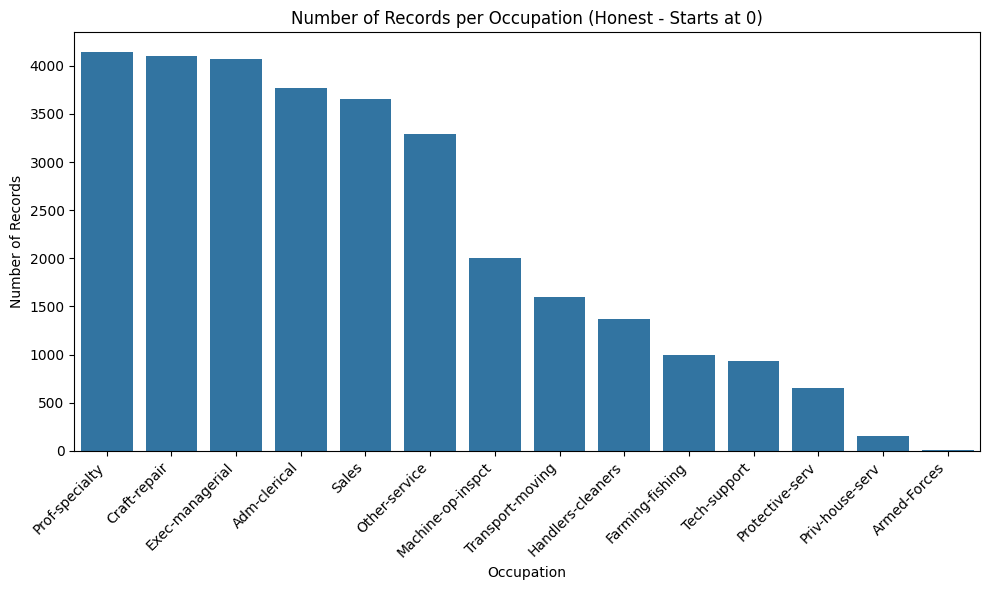

In [ ]:
#orignal
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='occupation', order=df_clean['occupation'].value_counts().index)
plt.xlabel('Occupation')
plt.ylabel('Number of Records')
plt.title('Number of Records per Occupation (Honest - Starts at 0)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

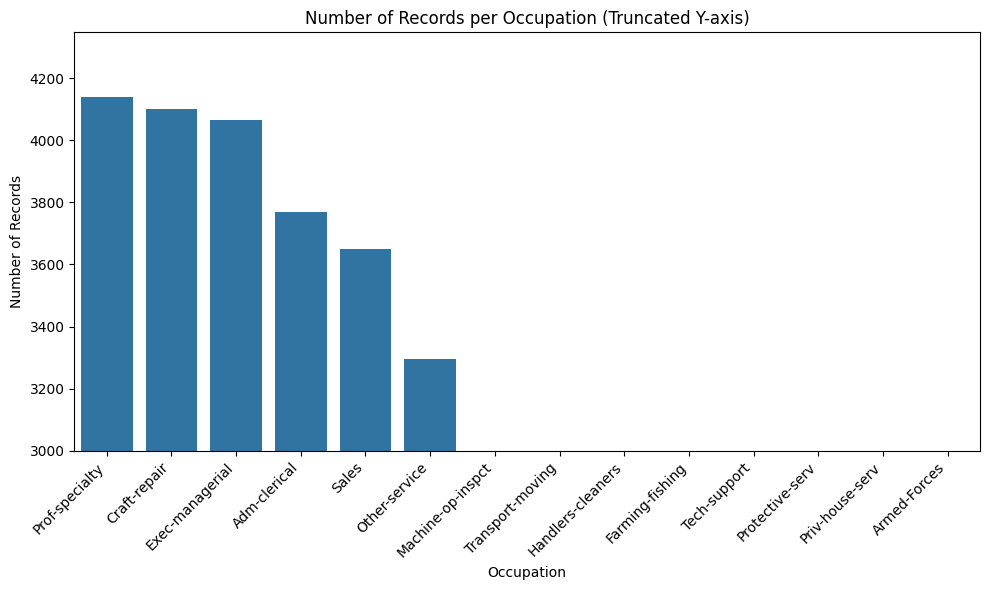

In [ ]:
#truncated. 
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='occupation', order=df_clean['occupation'].value_counts().index)
plt.xlabel('Occupation')
plt.ylabel('Number of Records')
plt.title('Number of Records per Occupation (Truncated Y-axis)')
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=3000) 
plt.tight_layout()
plt.show()

#### When the y-axis is truncated, differences between bars appear much larger than they actually are. For example, occupations with similar counts, even though the real difference is only around 20%. This distorts the viewer's perception of the data and can mislead people into thinking there's a bigger gap than truly exists exactly the kind of graphical integrity issue the manual warns against."